# Backgrounds Challenge — Baseline Evaluation
Evaluate a pretrained ResNet-50 on all IN-9 variations using standard PyTorch.

In [ ]:
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader

device = "cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"{torch.__version__=}")
print(f"Using {device=}")

In [12]:
# Download test data
!wget -q "https://github.com/MadryLab/backgrounds_challenge/releases/download/data/backgrounds_challenge_data.tar.gz"
!tar -xzf backgrounds_challenge_data.tar.gz
!ls bg_challenge/

fg_mask     mixed_rand	no_fg	   only_bg_t  original
mixed_next  mixed_same	only_bg_b  only_fg


In [13]:
# Download mapping: ImageNet class index (0-999) → IN-9 super-class (0-8)
!wget -q "https://raw.githubusercontent.com/Nabal22/Project-backgrounds-challenge/master/in_to_in9.json"

with open("in_to_in9.json") as f:
    in_to_in9 = json.load(f)

IN9_CLASSES = ['Dog', 'Bird', 'Vehicle', 'Reptile', 'Carnivore', 'Insect', 'Instrument', 'Primate', 'Fish']
print("Mapping loaded.")

Mapping loaded.


In [ ]:
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
model = model.to(device)
model.eval()
print("Model loaded.")

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

def evaluate(variation, data_root="bg_challenge", batch_size=64):
    dataset = datasets.ImageFolder(f"{data_root}/{variation}/val", transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    correct = 0
    total = 0
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu()
            # Map ImageNet predictions (0-999) → IN-9 (0-8)
            preds_in9 = torch.tensor([in_to_in9[str(p.item())] for p in preds])
            correct += (preds_in9 == targets).sum().item()
            total += targets.size(0)

    return correct / total

In [ ]:
variations = ["original", "mixed_same", "mixed_rand", "only_fg", "no_fg", "only_bg_t", "only_bg_b"]
results = {}

for var in variations:
    t0 = time.time()
    acc = evaluate(var)
    results[var] = acc
    print(f"{var:15s}: {acc*100:.1f}%  ({time.time()-t0:.0f}s)")

In [ ]:
print("\n=== BASELINE ResNet-50 ===")
for var, acc in results.items():
    print(f"  {var:15s}: {acc*100:.1f}%")

bg_gap = (results['mixed_same'] - results['mixed_rand']) * 100
print(f"\n  BG-Gap (mixed_same - mixed_rand): {bg_gap:.1f}%  (paper: 7.3%)")

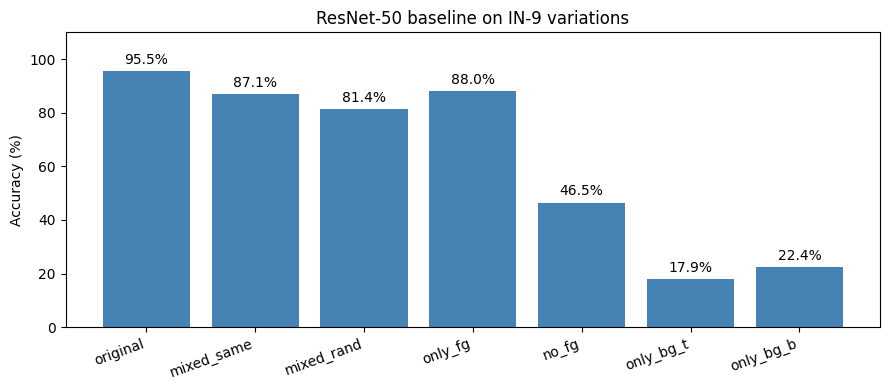

In [18]:
fig, ax = plt.subplots(figsize=(9, 4))
accs = [results[v] * 100 for v in variations]
bars = ax.bar(variations, accs, color='steelblue')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)')
ax.set_title('ResNet-50 baseline on IN-9 variations')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()